In [138]:
cd ..

e:\


In [140]:
#ensuring that any edits to libraries you make are reloaded here automatically
#to ensuere charts or images displayed are shown in this notebook
%reload_ext autoreload
%autoreload 2
%matplotlib inline 

In [ ]:
# Import required modules
import sys
from pathlib import Path

# Add project root to path
project_root = Path(r"E:\notebooks\MultimodalTweetsClassification")
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

# Import custom modules
from exp.Required_Modules_And_Packages import *
from sample_data.Data_Reading_And_Preprocessing import *
from exp.Required_Integration_Functionalities_For_Transformer_To_Fastai import *
from exp.Required_Functionalities_To_Handal_Multimodal_Dataset import *
from exp.Multimodal_Model_With_Intermediate_Or_EmbraceNet_Fusion import *

In [ ]:
# Check and install required dependencies
import sys
import subprocess
from pathlib import Path

def install_if_missing(package):
    try:
        __import__(package)
        print(f"{package} is already installed")
    except ImportError:
        print(f"Installing {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])

# Required packages
required_packages = ['fastai', 'transformers', 'torch', 'pandas', 'numpy', 'scikit-learn']
for package in required_packages:
    install_if_missing(package)

# Verify paths
project_root = Path(r"E:\notebooks\MultimodalTweetsClassification")
required_paths = [
    project_root / 'exp' / 'external' / 'aidrtokenize.py',
    project_root / 'exp' / 'external' / 'Precision_Module.py',
    project_root / 'sample_data' / 'Data_Reading_And_Preprocessing.py'
]

print("\nChecking required files:")
for path in required_paths:
    if path.exists():
        print(f"✓ Found: {path}")
    else:
        print(f"✗ Missing: {path}")

In [ ]:
# Fix and verify data paths
def get_data_paths():
    project_root = Path(r"E:\notebooks\MultimodalTweetsClassification")
    sample_data = project_root / 'sample_data'
    
    paths = {
        'humanitarian_task_tsv_files': (
            sample_data / 'task-humanitarian-text-img-agreed-lab-train.tsv',
            sample_data / 'task-humanitarian-text-img-agreed-lab-dev.tsv',
            sample_data / 'task-humanitarian-text-img-agreed-lab-test.tsv'
        ),
        'Informativeness_task_tsv_files': (
            sample_data / 'task_informative_text_img_agreed_lab_train.tsv',
            sample_data / 'task_informative_text_img_agreed_lab_dev.tsv',
            sample_data / 'task_informative_text_img_agreed_lab_test.tsv'
        )
    }
    
    print("Verifying data files:")
    all_exist = True
    for task, files in paths.items():
        print(f"\n{task}:")
        for f in files:
            if f.exists():
                print(f"✓ Found: {f}")
            else:
                print(f"✗ Missing: {f}")
                all_exist = False
    
    if not all_exist:
        raise FileNotFoundError("Some required data files are missing")
    
    return paths

# Verify data files
data_paths = get_data_paths()

In [142]:
import torch
import torch.nn as nn
from transformers import BertTokenizer, BertModel
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image

In [143]:
from transformers import BertTokenizer, BertForSequenceClassification
from exp.Required_Integration_Functionalities_For_Transformer_To_Fastai import (
    TransformersBaseTokenizer, TransformersVocab, CustomTransformerModel
)

In [ ]:
# Set the project root path
path = Path(r"E:\notebooks\MultimodalTweetsClassification")
print(f"Project root path: {path}")

In [ ]:
# Function to get data files paths
def get_tsv_data_files(task_name):
    sample_data = path / 'sample_data'
    
    if task_name == 'Informativeness_task_tsv_files':
        train_file = sample_data / 'task_informative_text_img_agreed_lab_train.tsv'
        dev_file = sample_data / 'task_informative_text_img_agreed_lab_dev.tsv'
        test_file = sample_data / 'task_informative_text_img_agreed_lab_test.tsv'
    else:
        raise ValueError(f"Unknown task: {task_name}")
    
    # Verify files exist
    for file_path in [train_file, dev_file, test_file]:
        if not file_path.exists():
            raise FileNotFoundError(f"Data file not found: {file_path}")
            
    return train_file, dev_file, test_file

# Function to read and process the dataframe
def get_dataframe(train_file, dev_file, test_file, path):
    # Read TSV files
    train_df = pd.read_csv(train_file, sep='\t')
    dev_df = pd.read_csv(dev_file, sep='\t')
    test_df = pd.read_csv(test_file, sep='\t')
    
    # Add is_valid column (0 for train, 1 for dev)
    train_df['is_valid'] = 0
    dev_df['is_valid'] = 1
    
    # Combine train and dev for training process
    data = pd.concat([train_df, dev_df], ignore_index=True)
    
    return data, test_df

In [145]:
path_img = path/'data_image'

In [ ]:
# Load the data
try:
    # Get train/dev and test data
    data_human_text_image, test_data_human_text_image = get_dataframe(
        *get_tsv_data_files('Informativeness_task_tsv_files'),
        path
    )
    print("Data loaded successfully!")
except Exception as e:
    print(f"Error loading data: {str(e)}")

reading data and preprocessing it.....
done!!
done!!


In [ ]:
# Display information about the datasets
print("Dataset Information:")
print("-" * 50)
print(f"Combined train/dev data shape: {data_human_text_image.shape}")
print("\nSplit sizes:")
print(f"Training set (is_valid=0): {data_human_text_image['is_valid'].value_counts().get(0, 0)} samples")
print(f"Validation set (is_valid=1): {data_human_text_image['is_valid'].value_counts().get(1, 0)} samples")
print("-" * 50)
print(f"Test data shape: {test_data_human_text_image.shape}")

# Display first few rows of the data
print("\nFirst few rows of the training data:")
print(data_human_text_image.head())

shape of data: (914, 10)

train set: 804
valid set: 110
shape of test data: (107, 9)



In [148]:
data_human_text_image.head()

,event_name,tweet_id,image_id,tweet_text,image,label,label_text,label_image,label_text_image,is_valid
0,srilanka_floods,8.700000e+17,869972354004393987_1,pak navy continues humanitarian assistance and...,data_image/srilanka_floods/31_5_2017/869972354...,informative,informative,informative,Positive,False
1,srilanka_floods,8.700000e+17,869972354004393987_2,pak navy continues humanitarian assistance and...,data_image/srilanka_floods/31_5_2017/869972354...,informative,informative,informative,Positive,False
2,srilanka_floods,8.700000e+17,869972354004393987_3,pak navy continues humanitarian assistance and...,data_image/srilanka_floods/31_5_2017/869972354...,informative,informative,informative,Positive,False
3,srilanka_floods,8.700000e+17,869977622377320448_0,sentinel was used to map the flood in matara s...,data_image/srilanka_floods/31_5_2017/869977622...,not_informative,informative,not_informative,Negative,False
4,srilanka_floods,8.700000e+17,869977622377320448_1,sentinel was used to map the flood in matara s...,data_image/srilanka_floods/31_5_2017/869977622...,informative,informative,not_informative,Negative,False


In [149]:
# Print column names
print("DataFrame columns:")
print(data_human_text_image.columns.tolist())
print("\nSample row:")
print(data_human_text_image.iloc[0])

DataFrame columns:
['event_name', 'tweet_id', 'image_id', 'tweet_text', 'image', 'label', 'label_text', 'label_image', 'label_text_image', 'is_valid']

Sample row:
event_name                                            srilanka_floods
tweet_id                                                      8.7e+17
image_id                                         869972354004393987_1
tweet_text          pak navy continues humanitarian assistance and...
image               data_image/srilanka_floods/31_5_2017/869972354...
label                                                     informative
label_text                                                informative
label_image                                               informative
label_text_image                                             Positive
is_valid                                                        False
Name: 0, dtype: object


# Multimodal Cross-Attention Fusion Implementation

We will implement:
1. Required imports
2. Image transforms and utilities
3. Multimodal dataset
4. Cross-attention fusion architecture
5. Training and evaluation pipeline

In [170]:
# 1. Required Imports
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import BertTokenizer, BertModel
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from tqdm.notebook import tqdm

# Visualization imports
import matplotlib.pyplot as plt
%matplotlib inline

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


In [151]:
# 2. Image Transforms and Constants
img_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Constants
MAX_LEN = 128
BATCH_SIZE = 16
EPOCHS = 5
LEARNING_RATE = 1e-4
NUM_ATTENTION_HEADS = 4

In [174]:
# 3. Multimodal Dataset
class MultimodalDataset(Dataset):
    def __init__(self, dataframe, tokenizer, img_transform, is_test=False):
        self.df = dataframe
        self.tokenizer = tokenizer
        self.img_transform = img_transform
        self.is_test = is_test
        
        # Define possible base paths for images
        self.possible_paths = [
            os.path.join(project_root, 'data', 'CrisisMMD_v2', 'images'),
            os.path.join(project_root, 'data', 'CrisisMMD_v2', 'data_images'),
            os.path.join(project_root, 'data', 'data_images'),
        ]
        
        # Check if any of the image directories exist
        self.base_path = None
        for path in self.possible_paths:
            if os.path.exists(path):
                self.base_path = path
                print(f"Using image directory: {path}")
                break
                
        if self.base_path is None:
            print("Warning: No valid image directory found. Please extract the dataset first.")
            print("Expected locations:")
            for path in self.possible_paths:
                print(f"- {path}")

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        text = str(row['tweet_text'])  # Ensure text is string
        
        # Construct image path
        event_name = str(row['event_name']).lower()  # Convert to lowercase
        image_id = str(row['image_id'])
        
        # Try different possible image extensions
        img_path = None
        if self.base_path is not None:
            for ext in ['', '.jpg', '.jpeg', '.png']:
                tmp_path = os.path.join(self.base_path, event_name, f"{image_id}{ext}")
                if os.path.exists(tmp_path):
                    img_path = tmp_path
                    break
        
        # Process text using encode_plus
        encoding = self.tokenizer.encode_plus(
            text,
            add_special_tokens=True,
            max_length=MAX_LEN,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )
        
        # Remove batch dimension added by return_tensors='pt'
        input_ids = encoding['input_ids'].squeeze()
        attention_mask = encoding['attention_mask'].squeeze()
        
        # Ensure tensors have the correct size
        if len(input_ids) < MAX_LEN:
            # Pad if necessary (shouldn't happen with padding='max_length')
            padding = torch.zeros(MAX_LEN - len(input_ids), dtype=torch.long)
            input_ids = torch.cat([input_ids, padding])
            attention_mask = torch.cat([attention_mask, padding])
        elif len(input_ids) > MAX_LEN:
            # Truncate if necessary (shouldn't happen with truncation=True)
            input_ids = input_ids[:MAX_LEN]
            attention_mask = attention_mask[:MAX_LEN]
        
        # Process image
        if img_path is not None and os.path.exists(img_path):
            try:
                image = Image.open(img_path).convert('RGB')
                image = self.img_transform(image)
            except Exception as e:
                print(f'Error processing image {img_path}: {str(e)}')
                image = torch.zeros(3, 224, 224)
        else:
            # If no valid image path found, use a blank image
            if idx == 0:  # Print warning only for first occurrence
                print(f'Warning: No valid image found for {image_id}. Using blank image.')
            image = torch.zeros(3, 224, 224)

        # Get label
        if not self.is_test:
            label = 1 if str(row['label_text']).lower().strip() == 'informative' else 0
            return input_ids, attention_mask, image, label
        return input_ids, attention_mask, image

In [153]:
# 4. Cross-Attention Fusion Architecture
class CrossAttentionFusion(nn.Module):
    def __init__(self, text_dim, img_dim, num_heads=4):
        super().__init__()
        self.img_proj = nn.Linear(img_dim, text_dim)
        self.layer_norm = nn.LayerNorm(text_dim)
        self.dropout = nn.Dropout(0.1)
        self.cross_attn = nn.MultiheadAttention(
            embed_dim=text_dim,
            num_heads=num_heads,
            dropout=0.1
        )

    def forward(self, text_emb, img_emb):
        # Project image embeddings to text dimension
        img_emb_proj = self.img_proj(img_emb).unsqueeze(1)  # [batch, 1, text_dim]
        
        # Prepare inputs for cross-attention (seq_len, batch, hidden)
        text_emb = text_emb.transpose(0, 1)  # [seq_len, batch, hidden]
        img_emb_proj = img_emb_proj.transpose(0, 1)  # [1, batch, hidden]
        
        # Cross-attention
        attn_output, _ = self.cross_attn(
            query=text_emb,
            key=img_emb_proj,
            value=img_emb_proj
        )
        
        # Convert back to batch first
        attn_output = attn_output.transpose(0, 1)  # [batch, seq_len, hidden]
        text_emb = text_emb.transpose(0, 1)  # [batch, seq_len, hidden]
        
        # Add & Norm
        fused = self.layer_norm(text_emb + self.dropout(attn_output))
        
        # Pool sequence dimension
        fused_pooled = fused.mean(dim=1)  # [batch, text_dim]
        return fused_pooled

class MultimodalCrossAttentionModel(nn.Module):
    def __init__(self, bert_model, resnet_model, fusion_module, num_labels):
        super().__init__()
        self.bert = bert_model
        self.resnet = resnet_model
        self.fusion = fusion_module
        self.classifier = nn.Sequential(
            nn.Linear(bert_model.config.hidden_size, 256),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(256, num_labels)
        )

    def forward(self, input_ids, attention_mask, images):
        # Get BERT embeddings
        bert_outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        # Handle both tuple return (old) and object return (new) from BERT
        text_emb = bert_outputs[0] if isinstance(bert_outputs, tuple) else bert_outputs.last_hidden_state
        
        # Get image embeddings
        img_emb = self.resnet(images)  # [batch, img_dim]

        # Fusion
        fused_emb = self.fusion(text_emb, img_emb)  # [batch, hidden_dim]

        # Classification
        logits = self.classifier(fused_emb)
        return logits

In [154]:
# 5. Load Models and Create Datasets
# Load BERT
model_path = r"e:\notebooks\MultimodalTweetsClassification\bert_model"
hf_tokenizer = BertTokenizer.from_pretrained(model_path)
bert_model = BertModel.from_pretrained(model_path)

# Load ResNet
resnet_model = models.resnet50(pretrained=True)
resnet_model.fc = nn.Identity()  # Output: [batch, 2048]

# Custom collate function
def collate_fn(batch):
    input_ids = torch.stack([item[0] for item in batch])
    attention_masks = torch.stack([item[1] for item in batch])
    images = torch.stack([item[2] for item in batch])
    if len(batch[0]) == 4:  # If labels are present
        labels = torch.tensor([item[3] for item in batch])
        return input_ids, attention_masks, images, labels
    return input_ids, attention_masks, images

# Create datasets
train_dataset = MultimodalDataset(
    dataframe=data_human_text_image[data_human_text_image['is_valid']==0],
    tokenizer=hf_tokenizer,
    img_transform=img_transform
)

val_dataset = MultimodalDataset(
    dataframe=data_human_text_image[data_human_text_image['is_valid']==1],
    tokenizer=hf_tokenizer,
    img_transform=img_transform
)

test_dataset = MultimodalDataset(
    dataframe=test_data_human_text_image,
    tokenizer=hf_tokenizer,
    img_transform=img_transform,
    is_test=True
)

# Create dataloaders with custom collate function
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, collate_fn=collate_fn)

print(f'Train samples: {len(train_dataset)}')
print(f'Validation samples: {len(val_dataset)}')
print(f'Test samples: {len(test_dataset)}')

Using image directory: E:\notebooks\MultimodalTweetsClassification\data\CrisisMMD_v2\data_image
Using image directory: E:\notebooks\MultimodalTweetsClassification\data\CrisisMMD_v2\data_image
Using image directory: E:\notebooks\MultimodalTweetsClassification\data\CrisisMMD_v2\data_image
Train samples: 804
Validation samples: 110
Test samples: 107


In [155]:
# 6. Initialize Model, Loss, and Optimizer
# Create fusion module and full model
fusion_module = CrossAttentionFusion(
    text_dim=bert_model.config.hidden_size,
    img_dim=2048,
    num_heads=NUM_ATTENTION_HEADS
)

model = MultimodalCrossAttentionModel(
    bert_model=bert_model,
    resnet_model=resnet_model,
    fusion_module=fusion_module,
    num_labels=2  # binary classification
)

model = model.to(device)

# Initialize loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)

# Learning rate scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.1,
    patience=2,
    verbose=True
)

In [160]:
# 7. Training and Validation Functions
def train_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []
    total_batches = len(train_loader)

    for batch_idx, (input_ids, attention_mask, images, labels) in enumerate(train_loader, 1):
        # Move data to device
        input_ids = input_ids.to(device)
        attention_mask = attention_mask.to(device)
        images = images.to(device)
        labels = labels.to(device)

        # Forward pass
        optimizer.zero_grad()
        outputs = model(input_ids, attention_mask, images)

        # Calculate loss
        loss = criterion(outputs, labels)
        total_loss += loss.item()

        # Backward pass
        loss.backward()
        optimizer.step()

        # Store predictions
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        # Print progress
        if batch_idx % 10 == 0:  # Print every 10 batches
            print(f'Training Batch [{batch_idx}/{total_batches}], Loss: {loss.item():.4f}')

    # Calculate metrics
    avg_loss = total_loss / len(train_loader)
    report = classification_report(all_labels, all_preds, target_names=['Non-Informative', 'Informative'])

    return avg_loss, report

def validate(model, val_loader, criterion, device, is_test=False):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []
    total_batches = len(val_loader)

    with torch.no_grad():
        for batch_idx, batch in enumerate(val_loader, 1):
            # Handle both test (3 items) and validation (4 items) cases
            if is_test:
                input_ids, attention_mask, images = batch
                labels = None
            else:
                input_ids, attention_mask, images, labels = batch

            # Move data to device
            input_ids = input_ids.to(device)
            attention_mask = attention_mask.to(device)
            images = images.to(device)
            if labels is not None:
                labels = labels.to(device)

            # Forward pass
            outputs = model(input_ids, attention_mask, images)

            # Calculate predictions
            preds = torch.argmax(outputs, dim=1)
            
            # Calculate loss and store metrics if labels are available
            if labels is not None:
                loss = criterion(outputs, labels)
                total_loss += loss.item()
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

                # Print progress
                if batch_idx % 10 == 0:
                    print(f'{"Test" if is_test else "Validation"} Batch [{batch_idx}/{total_batches}], Loss: {loss.item():.4f}')
            else:
                # For test set without labels, just store predictions
                all_preds.extend(preds.cpu().numpy())
                if batch_idx % 10 == 0:
                    print(f'Test Batch [{batch_idx}/{total_batches}]')

    # Return appropriate metrics based on whether labels are available
    if not is_test:
        avg_loss = total_loss / len(val_loader)
        report = classification_report(all_labels, all_preds, target_names=['Non-Informative', 'Informative'])
        return avg_loss, report
    else:
        return all_preds  # For test set, just return predictions

In [157]:
# 8. Training Loop
best_val_loss = float('inf')
for epoch in range(EPOCHS):
    print(f'\nEpoch {epoch+1}/{EPOCHS}')
    print('-' * 50)

    # Training phase
    train_loss, train_report = train_epoch(model, train_loader, criterion, optimizer, device)
    print(f'\nTraining Loss: {train_loss:.4f}')
    print('\nTraining Metrics:')
    print(train_report)

    # Validation phase
    val_loss, val_report = validate(model, val_loader, criterion, device)
    print(f'\nValidation Loss: {val_loss:.4f}')
    print('\nValidation Metrics:')
    print(val_report)

    # Learning rate scheduling
    scheduler.step(val_loss)

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_multimodal_model.pth')
        print('\nSaved best model!')

print('Training completed!')


Epoch 1/5
--------------------------------------------------
Training Batch [10/51], Loss: 0.0170
Training Batch [10/51], Loss: 0.0170
Training Batch [20/51], Loss: 0.0524
Training Batch [20/51], Loss: 0.0524
Training Batch [30/51], Loss: 0.0370
Training Batch [30/51], Loss: 0.0370
Training Batch [40/51], Loss: 0.1728
Training Batch [40/51], Loss: 0.1728
Training Batch [50/51], Loss: 0.0685
Training Batch [50/51], Loss: 0.0685

Training Loss: 0.1942

Training Metrics:
                 precision    recall  f1-score   support

Non-Informative       0.96      0.96      0.96       514
    Informative       0.92      0.92      0.92       290

       accuracy                           0.94       804
      macro avg       0.94      0.94      0.94       804
   weighted avg       0.94      0.94      0.94       804


Training Loss: 0.1942

Training Metrics:
                 precision    recall  f1-score   support

Non-Informative       0.96      0.96      0.96       514
    Informative       0.

Expected locations:
- E:\notebooks\MultimodalTweetsClassification\data\CrisisMMD_v2\images
- E:\notebooks\MultimodalTweetsClassification\data\CrisisMMD_v2\data_images
- E:\notebooks\MultimodalTweetsClassification\data\data_images
Test Set Evaluation:
--------------------------------------------------

Confusion Matrix:
--------------------------------------------------
                  Predicted
                  Non-Info  Info
Actual Non-Info    71       3
      Info         1        32

Accuracy: 0.9626

Detailed Classification Report:
                 precision    recall  f1-score   support

Non-Informative       0.99      0.96      0.97        74
    Informative       0.91      0.97      0.94        33

       accuracy                           0.96       107
      macro avg       0.95      0.96      0.96       107
   weighted avg       0.96      0.96      0.96       107


Confusion Matrix:
--------------------------------------------------
                  Predicted
            

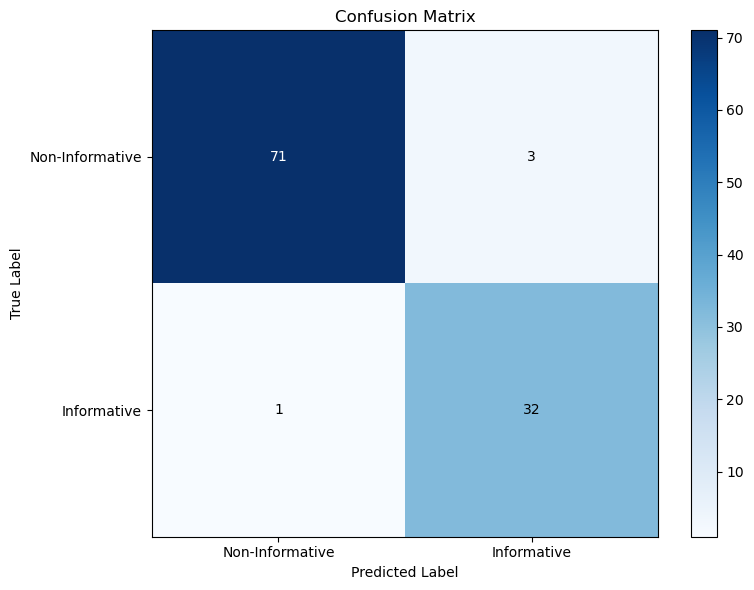

In [175]:
# 9. Evaluate on Test Set
# Load best model
model.load_state_dict(torch.load('best_multimodal_model.pth'))

# Check if test data has labels
has_labels = 'label_text' in test_data_human_text_image.columns

if has_labels:
    # Create test dataset with labels
    test_dataset_with_labels = MultimodalDataset(
        dataframe=test_data_human_text_image,
        tokenizer=hf_tokenizer,
        img_transform=img_transform,
        is_test=False  # Set to False to include labels
    )
    test_loader_with_labels = DataLoader(test_dataset_with_labels, batch_size=BATCH_SIZE, collate_fn=collate_fn)
    
    # Evaluate with metrics
    print('Test Set Evaluation:')
    print('-' * 50)
    
    # Get predictions and true labels
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for input_ids, attention_mask, images, labels in test_loader_with_labels:
            # Move to device
            input_ids = input_ids.to(device)
            attention_mask = attention_mask.to(device)
            images = images.to(device)
            labels = labels.to(device)
            
            # Get predictions
            outputs = model(input_ids, attention_mask, images)
            preds = torch.argmax(outputs, dim=1)
            
            # Store predictions and labels
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    # Convert to numpy arrays
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    
    # Calculate confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    
    # Calculate metrics
    accuracy = accuracy_score(all_labels, all_preds)
    report = classification_report(all_labels, all_preds, target_names=['Non-Informative', 'Informative'])
    
    # Print results
    print('\nConfusion Matrix:')
    print('-' * 50)
    print('                  Predicted')
    print('                  Non-Info  Info')
    print(f'Actual Non-Info    {cm[0,0]:<8} {cm[0,1]}')
    print(f'      Info         {cm[1,0]:<8} {cm[1,1]}')
    
    print('\nAccuracy:', f'{accuracy:.4f}')
    print('\nDetailed Classification Report:')
    print(report)
    
    # Visualize confusion matrix using matplotlib
    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    
    # Add colorbar
    plt.colorbar(im)
    
    # Add labels
    classes = ['Non-Informative', 'Informative']
    tick_marks = np.arange(len(classes))
    ax.set_xticks(tick_marks)
    ax.set_yticks(tick_marks)
    ax.set_xticklabels(classes)
    ax.set_yticklabels(classes)
    
    # Add numbers in cells
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], 'd'),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black")
    
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()
    
else:
    # If no labels available, just show predictions distribution
    print('Test Set Prediction (No ground truth labels available):')
    print('-' * 50)
    predictions = validate(model, test_loader, criterion, device, is_test=True)

    # Print prediction statistics
    print('\nPrediction Statistics:')
    print('-' * 50)
    unique, counts = np.unique(predictions, return_counts=True)
    prediction_counts = dict(zip(unique, counts))
    print('Predicted class distribution:')
    print(f'Non-Informative (0): {prediction_counts.get(0, 0)}')
    print(f'Informative (1): {prediction_counts.get(1, 0)}')

In [1]:
pip install torchvision

Note: you may need to restart the kernel to use updated packages.
